<a href="https://colab.research.google.com/github/rickyajs/Data-Science-2026/blob/main/Pertemuan_4_RickyArmandaJayaSirait_240401020219.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nama  : Ricky Armanda Jaya Sirait
# Nim   : 240401020219
#Kelas  : IF401
#Prodi  : PJJ S1 Informatika

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
sns.set_theme(style="whitegrid")

In [17]:
print("=== MEMUAT DATASET IRIS ===")
# Menggunakan dataset Iris bawaan Seaborn
df = sns.load_dataset('iris')
print("Dataset Iris berhasil dimuat.")
print(f"Dimensi data (baris, kolom): {df.shape}")
print("-" * 60)

=== MEMUAT DATASET IRIS ===
Dataset Iris berhasil dimuat.
Dimensi data (baris, kolom): (150, 5)
------------------------------------------------------------


In [13]:
print("=== RINGKASAN STATISTIK DESKRIPTIF ===")
# Menampilkan ringkasan statistik untuk semua fitur numerik
print(df.describe())
print("\n" + "-" * 60)

=== RINGKASAN STATISTIK DESKRIPTIF ===
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

------------------------------------------------------------


In [14]:
print("=== DISTRIBUSI FREKUENSI TARGET (SPECIES) ===")
# Menghitung jumlah data per kategori spesies tumbuhan
print(df['species'].value_counts())
print("-" * 60)

=== DISTRIBUSI FREKUENSI TARGET (SPECIES) ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
------------------------------------------------------------


In [15]:
print("=== ANALISIS KORELASI ===")
# Memisahkan kolom numerik saja untuk menghitung matriks korelasi Pearson
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
print("Matriks Korelasi Pearson:")
print(corr)

print("\nMencari Pasangan Fitur dengan Korelasi Tertinggi...")
# Membuat mask untuk menyembunyikan korelasi diagonal diri sendiri (nilai = 1)
mask = np.eye(corr.shape[0], dtype=bool)
corr_masked = corr.mask(mask)

# Menemukan pasangan dengan nilai korelasi absolut tertinggi
max_pair = corr_masked.abs().stack().idxmax()
print(f"Korelasi tertinggi ditemukan pada pasangan: {max_pair} = {corr.loc[max_pair]:.3f}")
print("-" * 60)

=== ANALISIS KORELASI ===
Matriks Korelasi Pearson:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000

Mencari Pasangan Fitur dengan Korelasi Tertinggi...
Korelasi tertinggi ditemukan pada pasangan: ('petal_length', 'petal_width') = 0.963
------------------------------------------------------------


=== MEMBUAT VISUALISASI GRAFIK ===


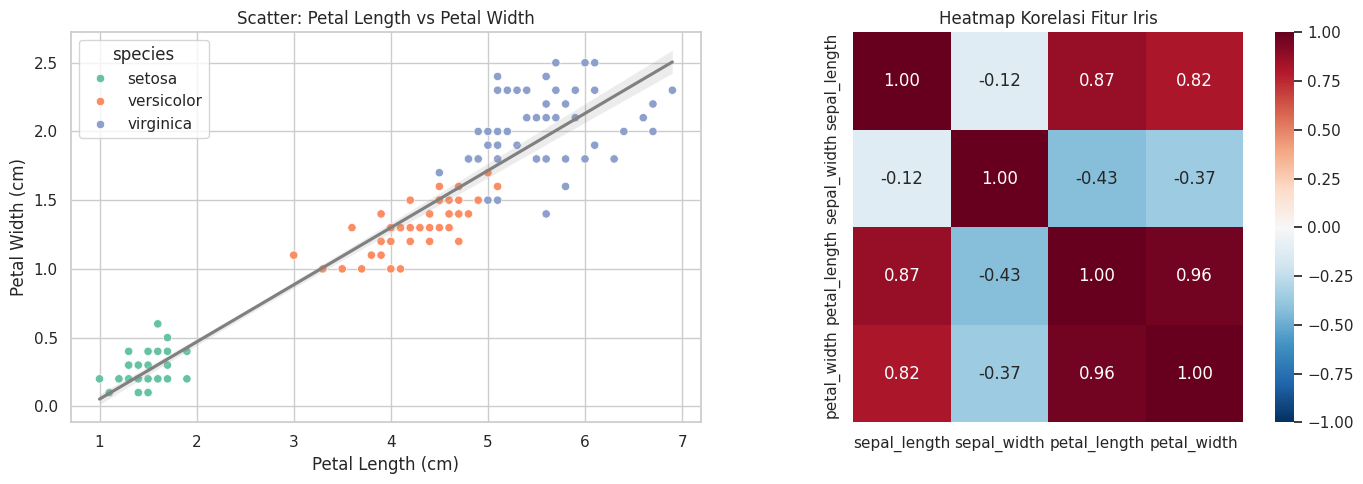

In [19]:
print("=== MEMBUAT VISUALISASI GRAFIK ===")

# Inisialisasi kanvas gambar dengan 1 baris dan 2 kolom sub-plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot pasangan paling berkorelasi kuat (petal_length vs petal_width)
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0]
)
# Menambahkan garis tren linear (regression line) di atas scatter plot
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)
axes[0].set_title('Scatter: Petal Length vs Petal Width')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Heatmap untuk matriks korelasi keseluruhan fitur
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)
axes[1].set_title('Heatmap Korelasi Fitur Iris')

# Menata ruang antar grafik agar rapi dan menampilkan ke layar
plt.tight_layout()
plt.show()
